In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from random import randrange
import warnings
from scipy import linalg    
import seaborn as sns
from scipy.stats import linregress
from scipy.spatial import Delaunay
from collections import defaultdict
warnings.filterwarnings('ignore')

datadir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/FrishmanMethod/"
plotsdir = "/Users/billiemeadowcroft/Dropbox/PostDocCode/FrishmanMethod/Plots/"
cmap = plt.cm.get_cmap('BuPu')
clrs=["#c7e9b4","#7fcdbb","#41b6c4","#1d91c0","#225ea8","#0c2c84","#c7e9b4","#7fcdbb","#41b6c4","#1d91c0","#225ea8","#0c2c84"]
clrs2=["#fef0d9","#edb873","#fc8d59","#d7301f","#4575b4","#313695","#313695","#4575b4","#91bfdb","#313695","#4575b4","#313695","#fef0d9","#fdcc8a","#fc8d59","#d7301f","#4575b4","#313695","#313695","#4575b4","#91bfdb","#313695","#4575b4","#313695"]

 Defining our basis functions

$L_k(r)$ Laguerre polynomials
The closed form is

$L_{n}(r)=\sum _{k=0}^{n}{\binom {n}{k}}{\frac {(-1)^{k}}{k!}}r^{k}.$

We want ours to -> 0 at large $r$ so we modulate by an exponential
$\phi_{n}(r)=L_{n}(r)e^{-r}$


Laguerre polynomials have the property that $rL'_{n}(r) = nL_{n}(r)-nL_{n-1}(r)$

In [2]:
# outputs vector of size NumBasisFunctions
def laguerre_polynomialsExp(r,NumBasisFunctions,r_mod):
    # Initialize Laguerre*exp(-r) and their derivatives
    L_exp = [np.exp(-r/r_mod), (1 - r) * np.exp(-r/r_mod)]
    #dL_exp = [-np.exp(-r/r_mod), (r - 2) * np.exp(-r/r_mod)]

    # Recursively build L_k(r) * exp(-r)
    L_plain = [1.0, 1 - r]  # plain Laguerre polynomials L_k(r)

    for k in range(2, NumBasisFunctions):
        # Compute next Laguerre polynomial
        Lk = ((2*k - 1 - r) * L_plain[k-1] - (k - 1) * L_plain[k-2]) / k
        L_plain.append(Lk)

        # Multiply by exp(-r)
        Lk_exp = Lk * np.exp(-r/r_mod)
        L_exp.append(Lk_exp)

        # Compute the derivative of L_k(r) * exp(-r)
        # Dlk = -Lk_exp*np.exp(-r/r_mod) + np.exp(-r/r_mod) * (1/r)* (k*Lk-k*L_plain[k-1])
        # dL_exp.append(Dlk)

    #print(np.shape(np.reshape(L_exp,5)))
    return L_exp #, dL_exp

Simulation definitions:

In [3]:
def parse_lammps_xyz(filename):
    data = []
    with open(filename, 'r') as file:
        while True:
            line = file.readline()
            if not line:
                break  # EOF
            
            if "ITEM: TIMESTEP" in line:
                timestep = int(file.readline().strip())
                file.readline()  # Skip "ITEM: NUMBER OF ATOMS"
                num_atoms = int(file.readline().strip())
                file.readline()  # Skip "ITEM: BOX BOUNDS ..."
                file.readline()
                file.readline()
                file.readline()
                file.readline()  # Skip "ITEM: ATOMS id type x y z"
                
                for _ in range(num_atoms):
                    atom_line = file.readline()
                    if not atom_line:
                        break  # Unexpected EOF
                    parts = atom_line.strip().split()
                    atom_id, atom_type = int(parts[0]), int(parts[1])
                    x, y, z = map(float, parts[2:5])
                    data.append({
                        "timestep": timestep,
                        "id": atom_id,
                        "type": atom_type,
                        "x": x,
                        "y": y,
                        "z": z
                    })

    df = pd.DataFrame(data)
    return df

# Unwrapping the trajectories
# The function unwrap_trajectories takes a DataFrame with atom trajectories and unwraps them based on periodic boundary conditions.

def unwrap_trajectories(df, box_length_x, box_length_y):
    # Sort the DataFrame by atom ID and timestep
    df = df.sort_values(by=["id", "timestep"]).copy()

    # Group by atom ID
    unwrapped_x = []
    unwrapped_y = []

    for atom_id, group in df.groupby("id"):
        group = group.sort_values(by="timestep").copy()
        x = group["x"].values
        y = group["y"].values
        timesteps = group["timestep"].values
        if x[0]<0:
            unwrappedX = [x[0]+box_length_x]
        elif x[0]>box_length_x:
            unwrappedX = [x[0]-box_length_x]
        else:
            unwrappedX = [x[0]]
        if y[0]<0:
            unwrappedY = [y[0]+box_length_y]
        elif y[0]>box_length_y:
            unwrappedY = [y[0]-box_length_y]
        else:
            unwrappedY = [y[0]]
        
        shiftX = 0
        shiftY = 0

        for i in range(1, len(x)):
            dx = x[i] - x[i - 1]
            dy = y[i] - y[i - 1]
            if dx > box_length_x / 2:
                shiftX -= box_length_x
            if dy > box_length_y / 2:
                shiftY -= box_length_y
            elif dx < -box_length_x / 2:
                shiftX += box_length_x
            elif dy < -box_length_y / 2:
                shiftY += box_length_y
            unwrappedX.append(x[i] + shiftX)
            unwrappedY.append(y[i] + shiftY)

        unwrapped_x.extend(unwrappedX)
        unwrapped_y.extend(unwrappedY)

    df["x_unwrapped"] = unwrapped_x
    df["y_unwrapped"] = unwrapped_y
    return df

# Function to write positions to .xyz file
def write_xyz(f, positions, step,box_length):
    #with open(f, 'a') as f:
    f.write("ITEM: TIMESTEP\n")
    f.write(f"{step}\n")
    f.write("ITEM: NUMBER OF ATOMS\n")
    f.write(f"{len(positions)}\n")
    # Write box dimensions (optional)
    f.write("ITEM: BOX BOUNDS pp pp pp\n")
    f.write(f"{-box_length/2} {box_length/2}\n")
    f.write(f"{-box_length/2} {box_length/2}\n")
    f.write(f"0.0 0.1\n")
    f.write("ITEM: ATOMS id type x y z\n")
    i=0
    for pos in positions:
        i+=1
        f.write(f"{i} 1 {pos[0]} {pos[1]} 0.0\n") 
        #f.write(f"1 {pos[0]} {pos[1]} 0.0\n")  # Assuming particles are Argon atoms
# Function to compute harmonic trap force
def harmonic_force(positions, kappa, center): 

    displacement = positions - center
    return -kappa * displacement
def compute_lj_forces(positions, box_size, epsilon, sigma, rcut):
    num_particles = len(positions)
    forces = np.zeros_like(positions)
    rcut2 = rcut ** 2
    sigma6 = sigma ** 6
    sigma12 = sigma6 ** 2
    force_scalar=0
    for i in range(num_particles):
        for j in range(i + 1, num_particles):
            # Minimum image convention
            rij = positions[i] - positions[j]
            rij -= box_size * np.round(rij / box_size)
            r2 = np.dot(rij, rij)
            
            if r2 < rcut2:
                inv_r2 = 1.0 / r2
                inv_r6 = inv_r2 ** 3
                inv_r12 = inv_r6 ** 2
                inv_r13 = (1/np.sqrt(r2))*inv_r12
                inv_r7 = (1/np.sqrt(r2))*inv_r6
                force_scalar = 48 * epsilon * (sigma12 * inv_r13 - 0.5 * sigma6 * inv_r7)
                    #24 * epsilon * inv_r2 * inv_r6 * (2 * sigma12 * inv_r6 - sigma6)
                force_vec = force_scalar * (rij/np.sqrt(r2))
                forces[i] += force_vec
                forces[j] -= force_vec
        #print('np.shape(force)',forces)
    return forces, force_scalar

def compute_soft_lj_forces(positions, box_size, epsilon, sigma, rcut, lambda_param):
    n,alpha_lj=1,0.5
    num_particles = len(positions)
    forces = np.zeros_like(positions)
    rcut2 = rcut ** 2
    lam_pow_n = lambda_param ** n
    const_factor = 4 * epsilon * lam_pow_n

    for i in range(num_particles):
        for j in range(i + 1, num_particles):
            rij = positions[i] - positions[j]
            rij -= box_size * np.round(rij / box_size)  # Periodic BC
            r2 = np.dot(rij, rij)

            if r2 < rcut2:
                r = np.sqrt(r2)
                r6 = (r / sigma) ** 6
                A = alpha_lj * (1 - lambda_param)**2 + r6
                dAdr = 6 * (r / sigma)**5 / sigma
                dEdr = const_factor * (-2 / A**3 + 1 / A**2) * dAdr
                force_vec = -dEdr * (rij / r)
                forces[i] += force_vec
                forces[j] -= force_vec

    return forces, -dEdr

# def soft_lj_force(r, epsilon, sigma, rcut, lambda_param):
#     n = 1
#     alpha_lj = 0.5

#     if r >= rcut:
#         return 0.0  # zero force beyond cutoff

#     lam_pow_n = lambda_param ** n
#     const_factor = 4 * epsilon * lam_pow_n

#     r6 = (r / sigma) ** 6
#     A = alpha_lj * (1 - lambda_param)**2 + r6
#     dAdr = 6 * (r / sigma)**5 / sigma

#     dEdr = const_factor * (-2 / A**3 + 1 / A**2) * dAdr

#     return -dEdr  # negative gradient = force

def soft_lj_force(r, epsilon, sigma, rcut, lambda_param):
    n = 1
    alpha_lj = 0.5
    """Compute scalar magnitude of soft LJ/cut force for distance r."""
    if r >= rcut or r <= 1e-12:
        return 0.0

    lam_pow_n = lambda_param ** n
    r_over_sigma = r / sigma
    r6 = r_over_sigma ** 6
    A = alpha_lj * (1 - lambda_param)**2 + r6
    dAdr = (6 * r**5) / (sigma**6)

    prefactor = 4 * epsilon * lam_pow_n
    dEdr = prefactor * (2 / A**3 - 1 / A**2) * dAdr

    return -dEdr

def lj_force(r, epsilon, sigma, rcut):
    #n = 1
    #alpha_lj = 0.5
    """Compute scalar magnitude of soft LJ/cut force for distance r."""
    if r >= rcut or r <= 1e-12:
        return 0.0

    #lam_pow_n = lambda_param ** n
    r_over_sigma = r / sigma
    r6 = r_over_sigma ** 6
    A = r6
    dAdr = (6 * r**5) / (sigma**6)
    prefactor = 4 * epsilon * 1
    dEdr = prefactor * (2 / A**3 - 1 / A**2) * dAdr

    print('prefactor',prefactor)
    print('dAdr',dAdr)
    print('(2 / A**3 - 1 / A**2)',(2 / A**3 - 1 / A**2))

    return -dEdr



Simulation itself:

In [4]:
def OD_MD_SimulationLJPairs(num_particles, box_size, kappa, temperature, gamma, dt,
                     num_steps0, equilibration_steps, frame, use_harmonic_trap,
                     name, center, epsilon, sigma, rcut,lambda_param):
    # Initialize particle positions randomly within the box
    positions = np.random.uniform(-box_size / 20, box_size / 20, size=(num_particles, 2)) #
    #adding positions and making sure no overlap
    #start particles in a grid at the center of the box
    # for i in range(num_particles):
    #     positions[i][0] = (i % 5) * (box_size / 30) - box_size / 30
    #     positions[i][1] = (i // 5) * (box_size / 30) - box_size / 30

    for i in range(num_particles):
        for j in range(i):
            while np.linalg.norm(positions[i] - positions[j]) < (sigma+0.1):
                positions[i] = np.random.uniform(-box_size / 2, box_size / 2, size=(2,))
    #print(positions)
    #positions = np.array([np.array([0, sigma+0.1]),np.array([0,0])])
    #print(positions)

    rng = np.random.default_rng()
    num_steps = num_steps0 + equilibration_steps
    min_ljForce = 0
    for step in range(num_steps):
        if step % 1000 == 0:
            print(f"Step {step}/{num_steps}")
        noise = rng.normal(0, np.sqrt(2 * temperature * gamma / dt), size=(num_particles, 2))
        #noise = rng.normal(0, np.sqrt(2 * temperature * dt / gamma), size=(num_particles, 2))
        # Compute LJ forces
        
        lj_force, scalarFLJ = compute_soft_lj_forces(positions, box_size, epsilon, sigma, rcut, lambda_param) #compute_lj_forces(positions, box_size, epsilon, sigma, rcut)
        if scalarFLJ < min_ljForce:
            min_ljForce = scalarFLJ
        #print('np.shape(lj_force)',np.shape(lj_force))
        if use_harmonic_trap:
            trap_force = harmonic_force(positions, kappa, center)
        else:
            trap_force = 0

        # Update positions
        positions += (lj_force + trap_force + noise) * dt / gamma

        # Apply periodic boundary conditions
        positions = (positions + box_size / 2) % box_size - box_size / 2

        if step == 0:
            f = open("/Users/billiemeadowcroft/Dropbox/PostDocCode/FrishmanMethod/" + name, 'w')

        if step % frame == 0 and step > equilibration_steps:
            f = open("/Users/billiemeadowcroft/Dropbox/PostDocCode/FrishmanMethod/" + name, 'a')
            write_xyz(f, positions, step,box_size)

        if step == num_steps - 1:
            f.close()
            print("Simulation completed. Output written to " + name)
            print("Minimum force " + str(min_ljForce)+"for params eps"+str(epsilon)+" sig"+str(sigma)+" rc"+str(rcut))

Pairwise force inference:

In [5]:
def check_cs(df_atoms, Bm05,NumBasisFunctions,L_x,L_y,r_mod,rcut_yes,rcut_inf):
    # Initialize a matrix to store the time-averaged product of c_alpha and c_beta
    timesteps = df_atoms['timestep'].unique()
    #D = NumBasisFunctions
    df_atoms = df_atoms.sort_values(by=["id", "timestep"]).copy()
    #B_accum = np.zeros((D, D))
    c_alpha_beta_sum = np.zeros((NumBasisFunctions, NumBasisFunctions))
    NumAtoms = np.max(df_atoms.id)
    count = 0
    for t in timesteps:
        df_t = df_atoms[df_atoms['timestep'] == t]
        if len(df_t) != NumAtoms:
            print(f"Skipping timestep {t} due to incomplete data.")
            continue  # skip incomplete timesteps
        coords = df_t.sort_values('id')[['x', 'y']].values  # ensure ordered by id
        for i in range(NumAtoms):
            for j in range(i+1,NumAtoms):
                dx = coords[j, 0] - coords[i, 0] ## dx direction is towards atom j
                dy = coords[j, 1] - coords[i, 1]
                dx = dx - L_x * np.round(dx / L_x)
                dy = dy - L_y * np.round(dy / L_y)
                rij = np.sqrt(dx**2 + dy**2)
                if rcut_yes == True:
                    if rij > rcut_inf:
                        continue
                count += 1
                b = laguerre_polynomialsExp(rij,NumBasisFunctions,r_mod)
                c = Bm05.dot(b)
                c_alpha_beta_sum += np.outer(c, c)  # Outer product of c with itself

    # Compute the time average
    c_alpha_beta_avg = c_alpha_beta_sum / (count)

    print("<c_alpha.c_beta> should be Identity matrix:\n", c_alpha_beta_avg)

2 particle pair interactions

In [13]:
# this works well for 'correct' basis r^-7,r^-13 with LJ particles
def estmateforces2PairLJ(NumBins,df_atoms,L_x,L_y,dt,gamma,sigma,kappa,center,bin_edges,epsilon,r_mod):
    # Initialize lists to store results
    timesteps = df_atoms['timestep'].unique()
    D = 2
    df_atoms = df_atoms.sort_values(by=["id", "timestep"]).copy()
    B_accum = np.zeros((D, D))
    NumAtoms = np.max(df_atoms.id)
    count = 0
    for t in timesteps:
        df_t = df_atoms[df_atoms['timestep'] == t]
        if len(df_t) != NumAtoms:
            print(f"Skipping timestep {t} due to incomplete data.")
            continue  # skip incomplete timesteps

        coords = df_t.sort_values('id')[['x', 'y']].values  # ensure ordered by id
        for i in range(NumAtoms):
            for j in range(i+1,NumAtoms):
                dx = coords[j, 0] - coords[i, 0] ## dx direction is towards atom j
                dy = coords[j, 1] - coords[i, 1]
                dx = dx - L_x * np.round(dx / L_x)
                dy = dy - L_y * np.round(dy / L_y)
                rij = np.sqrt(dx**2 + dy**2)
                #rij2 = rij**2
                b1= 1/(rij**7)
                b2= 1/(rij**13)
                basis_vec = [b1, b2]
                B_accum += np.outer(basis_vec, basis_vec) #adding twice because I have to add twice with force inference and the speed of particle i and j
                B_accum += np.outer(basis_vec, basis_vec)
                count += 2
    if count == 0:
        print("No valid timesteps found.")
        return None
    # Average over timesteps
    B = B_accum / count
    if np.linalg.cond(B) > 1e10:
        raise ValueError("Matrix B is ill-conditioned.")
    print("shape of B",np.shape(B))
    Bm1 = linalg.inv(B)
    Bm05 = linalg.sqrtm(Bm1)
    
    #unwrapped_single_atom = unwrap_trajectories(df_atoms, L_x, L_y)  # Unwrap trajectories
    r_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    timesteps = df_atoms['timestep'].unique()

    CCs = np.zeros((D,NumBins))
    FF_accum = np.zeros((1,D)) ##these will be dotted at the end
    
    TruForce = np.zeros((NumBins))
    for k, r in enumerate(r_centers):
        b = [1/(r**7),1/(r**13)]
        c = Bm05 @ b
        CCs[:,k] = c
        TruForce[k] = 48 * epsilon *(((sigma)**12/r**13) - 0.5*((sigma)**6/r**7))/gamma

    Lentraj = 0
    for t_idx in range(len(timesteps) - 1):
        t1, t2 = timesteps[t_idx], timesteps[t_idx + 1]
        frame1 = df_atoms[df_atoms['timestep'] == t1].sort_values('id')
        frame2 = df_atoms[df_atoms['timestep'] == t2].sort_values('id')
        pos1 = frame1[['x', 'y']].values
        pos2 = frame2[['x', 'y']].values
        if len(frame1) != NumAtoms:
            print('lost an atom')
            continue
        ddt = float((t2 - t1) * dt)
        
        for i in range(NumAtoms):
            dxi = pos2[i, 0] - pos1[i, 0]
            dyi = pos2[i, 1] - pos1[i, 1]
            dxi = dxi - L_x * np.round(dxi / L_x)
            dyi = dyi - L_y * np.round(dyi / L_y)
            velsvec_i = [dxi/ ddt,dyi/ ddt]  #velocity vector of particle i
            
            if dxi >= L_x or dyi >= L_y: #dxi > L_y or dyi > L_y:
                print("dx wrapped bigger than L_x in velocity calculation I")
            
            for j in range(i+1,NumAtoms):
                #dxj = pos2UW[j, 0] - pos1UW[j, 0]
                #dyj = pos2UW[j, 1] - pos1UW[j, 1]
                dxj = pos2[j, 0] - pos1[j, 0]
                dyj = pos2[j, 1] - pos1[j, 1]
                dxj = dxj - L_x * np.round(dxj / L_x)
                dyj = dyj - L_y * np.round(dyj / L_y)
                
                velsvec_j = [dxj/ ddt,dyj/ ddt]  #velocity vector of particle j
                if dxj >= L_x or dyj >= L_y: #dxi > L_y or dyi > L_y:
                    print("dx wrapped bigger than L_x in velocity calculation J")
            
                dxij = pos1[j, 0] - pos1[i, 0]
                dyij = pos1[j, 1] - pos1[i, 1]
                dxij = dxij - L_x * np.round(dxij / L_x)
                dyij = dyij - L_y * np.round(dyij / L_y)      

                if dxij > L_x or dyij > L_y: #dxij > L_x or dyij>L_x:
                    print("dx wrapped bigger than L_x in pairwise distance calculation")

                rij = np.sqrt(dxij**2 + dyij**2) #the distance between particles i and j at start time point t1

                #Normalised r_ij vector
                r_ijVec = np.array([dxij,dyij])/rij 
                
                b1 = 1/(rij**7)
                b2 = 1/(rij**13)
                velsvec_Parali= np.dot(velsvec_i,-r_ijVec) # projection of velocity i onto the vector connecting i and j
                velsvec_Perpi = velsvec_i-velsvec_Parali
                velsvec_Paralj= np.dot(velsvec_j,r_ijVec) # j dotted with vector j->i
                velsvec_Perpj = velsvec_j-velsvec_Paralj
                
                #Now calculate the F_r_alpha =DeltaX*C_alpha for this pair at this time
                phi = np.array([b1, b2])
                c = Bm05 @ phi

                FF_accum += np.outer(velsvec_Parali,c)
                FF_accum += np.outer(velsvec_Paralj,c)
                #FF2_accum += np.outer(velsvec_Parali,c)
                #FF2_accum += np.outer(velsvec_Paralj,c)
                Lentraj += 2

    #print("dimension of velsAv",np.shape(velsvec))
    print("dimension of FF_accum",np.shape(FF_accum))
    FF = FF_accum/Lentraj
    #FF2 = FF2_accum/Lentraj
    print('dimension of CCs',np.shape(CCs))
    Finfer = FF.dot(CCs)
    #Finfer2 = FF2.dot(CCs)
    return Finfer,CCs, FF, TruForce


Make a triangular net for your particles to find topological neighbours

In [14]:
def build_triangulation_neighbors(df):
    """
    Builds a neighbor map from Delaunay triangulation of 2D points.
    
    Parameters:
        df (pd.DataFrame): must contain 'x', 'y', and 'id' columns.
        
    Returns:
        neighbors (dict): maps id -> set of connected neighbor ids.
        tri (Delaunay object): the triangulation object (optional, useful for plotting).
    """
    coords = df[['x', 'y']].values
    ids = df['id'].values
   
    tri = Delaunay(coords)

    # Map triangle vertex indices to actual IDs
    neighbors = defaultdict(set)

    for simplex in tri.simplices:  # Each simplex is a triangle of indices into coords
        id0, id1, id2 = ids[simplex[0]], ids[simplex[1]], ids[simplex[2]]
        neighbors[id0].update([id1, id2])
        neighbors[id1].update([id0, id2])
        neighbors[id2].update([id0, id1])

    return dict(neighbors)

def build_triangulation_neighbors_pbc(df, L_x, L_y):
    """
    Constructs a Delaunay-based neighbor graph with periodic boundary conditions (PBC).

    Parameters:
        df (pd.DataFrame): Must contain 'x', 'y', and 'id'
        L_x, L_y (float): Box dimensions

    Returns:
        neighbors (dict): id -> set of neighbor ids (minimum image neighbors)
    """
    coords = df[['x', 'y']].values
    ids = df['id'].values
    N = len(df)
    #print("coord values",coords)
    # Tile points in 3x3 grid
    tiled_coords = []
    tiled_ids = []

    shifts = [-1, 0, 1]
    for dx in shifts:
        for dy in shifts:
            shifted = coords + np.array([dx * L_x, dy * L_y])
            tiled_coords.append(shifted)
            tiled_ids.append(ids)

    tiled_coords = np.vstack(tiled_coords)
    tiled_ids = np.hstack(tiled_ids)

    tri = Delaunay(tiled_coords)

    # Only retain triangles whose centroids lie within the original box
    mask = np.all(
        (np.mean(tiled_coords[tri.simplices], axis=1) >= [0, 0]) &
        (np.mean(tiled_coords[tri.simplices], axis=1) <= [L_x, L_y]),
        axis=1
    )

    neighbors = defaultdict(set)

    for simplex in tri.simplices[mask]:
        for i in range(3):
            for j in range(i+1, 3):
                id_i = tiled_ids[simplex[i]]
                id_j = tiled_ids[simplex[j]]
                if id_i != id_j:  # avoid self-linking
                    neighbors[id_i].add(id_j)
                    neighbors[id_j].add(id_i)

    return dict(neighbors)


Take your trajectory and output the average distance to the topological nearest neighbours

In [15]:
def Get_Distance_Quantities(df_atoms,L_x,L_y):
    timesteps = df_atoms['timestep'].unique()
    df_atoms = df_atoms.sort_values(by=["id", "timestep"]).copy()
    NumAtoms = np.max(df_atoms.id)
    r_IJav = []
    AvNumNeighs = []
    R_n1 = []
    R_all = []
    for t in timesteps:
        if t%(len(timesteps)//10) == 0:
            print(f"Processing timestep {t}/{timesteps[-1]}")
        frame1 = df_atoms[df_atoms['timestep'] == t].sort_values('id')
        pos1 = frame1[['x', 'y']].values
        # flag if pos1 has NaNs
        if np.any(np.isnan(pos1)):
            print(f"NaN values found in positions at timestep {t}. Skipping this timestep.")
            #continue
        # make sure pos1 has the right number of atoms
        #print("shape of pos1",np.shape(frame1),"NumAtoms",NumAtoms)
        if len(pos1) != NumAtoms:
            print(f"Skipping timestep {t} due to incomplete data.")
            #continue

        #neighbours= build_triangulation_neighbors(frame1) 
        neighbours=build_triangulation_neighbors_pbc(frame1, L_x, L_y)
        for i in range(NumAtoms):
            NeighIDs = neighbours.get(i+1, set())  # +1 because ids are 1-based in the DataFrame
            NeighIDs = [n for n in NeighIDs if n <= NumAtoms]
            JAtoms = len(NeighIDs)
            AvNumNeighs.append(JAtoms)
            closest_r = 0
            for j in range(i+1,NumAtoms):
                #j = NeighIDs[jj]-1
                dxij = pos1[j, 0] - pos1[i, 0]
                dyij = pos1[j, 1] - pos1[i, 1]
                dxij = dxij - L_x * np.round(dxij / L_x)
                dyij = dyij - L_y * np.round(dyij / L_y)  
                rij = np.sqrt(dxij**2 + dyij**2)
                R_all.append(rij)
                if j==i+1:
                    closest_r = rij
                elif rij < closest_r:
                    closest_r = rij
                if j in NeighIDs:
                    r_IJav.append(rij)
                
            R_n1.append(closest_r)
    #bin or hist R_all
    bin_width = (max(R_all) - min(R_all)) / 50  # Adjust bin width as needed
    bins = np.arange(min(R_all), max(R_all) + bin_width, bin_width)
    indices = np.digitize(R_all, bins)
    counts = np.bincount(indices)
    # Find mode bin (bin with highest count)
    mode_bin_index = np.argmax(counts)
    mode_bin_range = (bins[mode_bin_index - 1], bins[mode_bin_index])  # bin edges
    return np.mean(r_IJav),np.mean(R_n1),mode_bin_range,np.mean(AvNumNeighs)

Multiple pair interactions

In [28]:
def estmateforcesMultiPairLJ(NumBins,df_atoms,L_x,L_y,dt,gamma,sigma,kappa,center,bin_edges,epsilon,NumBasisFunctions,OnlyNN,rcut_inf,rcut_yes,r_mod,lambda_param):
    # Initialize lists to store results
    timesteps = df_atoms['timestep'].unique()
    D = NumBasisFunctions
    df_atoms = df_atoms.sort_values(by=["id", "timestep"]).copy()
    B_accum = np.zeros((D, D))
    NumAtoms = np.max(df_atoms.id)
    count = 0
    print("r_modulation",r_mod)
    for t in timesteps:
        df_t = df_atoms[df_atoms['timestep'] == t]
        if len(df_t) != NumAtoms:
            print(f"Skipping timestep {t} due to incomplete data.")
            continue  # skip incomplete timesteps

        coords = df_t.sort_values('id')[['x', 'y']].values  # ensure ordered by id
        for i in range(NumAtoms):
            for j in range(i+1,NumAtoms):
                dx = coords[j, 0] - coords[i, 0] ## dx direction is towards atom j
                dy = coords[j, 1] - coords[i, 1]
                dx = dx - L_x * np.round(dx / L_x)
                dy = dy - L_y * np.round(dy / L_y)
                rij = np.sqrt(dx**2 + dy**2)
                if rcut_yes == True:
                    if rij > rcut_inf:
                        continue
                basis_vec = laguerre_polynomialsExp(rij,NumBasisFunctions,r_mod)
                B_accum += np.outer(basis_vec, basis_vec) #adding twice because I have to add twice with force inference and the speed of particle i and j
                B_accum += np.outer(basis_vec, basis_vec)
                count += 2
    if count == 0:
        print("No valid timesteps found.")
        return None
    # Average over timesteps
    B = B_accum / count
    #if np.linalg.cond(B) > 1e10:
    #    raise ValueError("Matrix B is ill-conditioned.")
    print("shape of B",np.shape(B))
    eigvals = np.linalg.eigvalsh(B)
    print("Eigenvalues of B:", eigvals)
    Bm1 = linalg.inv(B)
    Bm05 = linalg.sqrtm(Bm1)
   # check_cs(df_atoms,Bm05,NumBasisFunctions,L_x,L_y,r_mod,rcut_yes,rcut_inf)
    
    #unwrapped_single_atom = unwrap_trajectories(df_atoms, L_x, L_y)  # Unwrap trajectories
    r_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    timesteps = df_atoms['timestep'].unique()

    CCs = np.zeros((NumBasisFunctions,NumBins))
    FF_accum = np.zeros((1,D)) ##these will be dotted at the end
    Rhist = []
    TruForce = np.zeros((NumBins))
    for k, r in enumerate(r_centers):
        b = laguerre_polynomialsExp(r,NumBasisFunctions,r_mod)
        c = Bm05 @ b
        CCs[:,k] = c
        TruForce[k] = soft_lj_force(r, epsilon, sigma, rcut_inf, lambda_param) #48 * epsilon *(((sigma)**12/r**13) - 0.5*((sigma)**6/r**7))/gamma

    Lentraj = 0
    for t_idx in range(len(timesteps) - 1):
        t1, t2 = timesteps[t_idx], timesteps[t_idx + 1]
        frame1 = df_atoms[df_atoms['timestep'] == t1].sort_values('id')
        frame2 = df_atoms[df_atoms['timestep'] == t2].sort_values('id')
        pos1 = frame1[['x', 'y']].values
        pos2 = frame2[['x', 'y']].values
        if len(frame1) != NumAtoms:
            print('lost an atom')
            continue
        ddt = float((t2 - t1) * dt)
        if OnlyNN==True:
            neighbours= build_triangulation_neighbors_pbc(frame1, L_x, L_y) #build_triangulation_neighbors(frame1)
        # if t_idx % 100 == 0:
        #     print("building neighbours for particle",i)
        #     
        #     print("i,neighbours,tri",i,neighbours,tri)
        for i in range(NumAtoms):
            dxi = pos2[i, 0] - pos1[i, 0]
            dyi = pos2[i, 1] - pos1[i, 1]
            dxi = dxi - L_x * np.round(dxi / L_x)
            dyi = dyi - L_y * np.round(dyi / L_y)
            velsvec_i = [dxi/ ddt,dyi/ ddt]  #velocity vector of particle i
            
            if dxi >= L_x or dyi >= L_y: #dxi > L_y or dyi > L_y:
                print("dx wrapped bigger than L_x in velocity calculation I")
            if OnlyNN==True:
                NeighIDs = neighbours.get(i+1, set())  # +1 because ids are 1-based in the DataFrame
                NeighIDs = [n for n in NeighIDs if n <= NumAtoms]
                JAtoms = len(NeighIDs)
            else:
                JAtoms = NumAtoms 
            if OnlyNN==True:
                if len(NeighIDs) == 0:
                    print(f"No neighbors found for particle {i+1} at timestep {t1}. Skipping.")
                    continue

            for jj in range(i+1,JAtoms):
                if OnlyNN==True:
                    j = NeighIDs[jj]-1
                else:
                    j=jj
                dxj = pos2[j, 0] - pos1[j, 0]
                dyj = pos2[j, 1] - pos1[j, 1]
                dxj = dxj - L_x * np.round(dxj / L_x)
                dyj = dyj - L_y * np.round(dyj / L_y)
                
                velsvec_j = [dxj/ ddt,dyj/ ddt]  #velocity vector of particle j
                if dxj >= L_x or dyj >= L_y: #dxi > L_y or dyi > L_y:
                    print("dx wrapped bigger than L_x in velocity calculation J")
            
                dxij = pos1[j, 0] - pos1[i, 0]
                dyij = pos1[j, 1] - pos1[i, 1]
                dxij = dxij - L_x * np.round(dxij / L_x)
                dyij = dyij - L_y * np.round(dyij / L_y)      

                if dxij > L_x or dyij > L_y: #dxij > L_x or dyij>L_x:
                    print("dx wrapped bigger than L_x in pairwise distance calculation")

                rij = np.sqrt(dxij**2 + dyij**2) #the distance between particles i and j at start time point t1
                if rcut_yes == True:
                    if rij > rcut_inf:
                        continue
                Rhist.append(rij)
                #Normalised r_ij vector
                r_ijVec = np.array([dxij,dyij])/rij 
                
                #b1 = 1/(rij**7)
                #b2 = 1/(rij**13)
                velsvec_Parali= np.dot(velsvec_i,-r_ijVec) # projection of velocity i onto the vector connecting i and j
                velsvec_Perpi = velsvec_i-velsvec_Parali
                velsvec_Paralj= np.dot(velsvec_j,r_ijVec) # j dotted with vector j->i
                velsvec_Perpj = velsvec_j-velsvec_Paralj
                
                #Now calculate the F_r_alpha =DeltaX*C_alpha for this pair at this time
                phi = laguerre_polynomialsExp(rij,NumBasisFunctions,r_mod)
                c = Bm05 @ phi
                if np.iscomplexobj(c): ## hmm should find out why it would be complex though...
                    c = c.real
                FF_accum += np.outer(velsvec_Parali,c)
                FF_accum += np.outer(velsvec_Paralj,c)
                #FF2_accum += np.outer(velsvec_Parali,c)
                #FF2_accum += np.outer(velsvec_Paralj,c)
                Lentraj += 2

    #print("dimension of velsAv",np.shape(velsvec))
    print("dimension of FF_accum",np.shape(FF_accum))
    FF = FF_accum/Lentraj
    #FF2 = FF2_accum/Lentraj
    print('dimension of CCs',np.shape(CCs))
    Finfer = FF.dot(CCs)
    #Finfer2 = FF2.dot(CCs)
    return Finfer,CCs, FF, TruForce,Rhist


Step 0/21000
Step 1000/21000
Step 2000/21000
Step 3000/21000
Step 4000/21000
Step 5000/21000
Step 6000/21000
Step 7000/21000
Step 8000/21000
Step 9000/21000
Step 10000/21000
Step 11000/21000
Step 12000/21000
Step 13000/21000
Step 14000/21000
Step 15000/21000
Step 16000/21000
Step 17000/21000
Step 18000/21000
Step 19000/21000
Step 20000/21000
Simulation completed. Output written to outputSig5N3lambda1.xyz
Minimum force -0.23963992261078657for params eps0.5 sig5 rc11
Parsing LAMMPS XYZ file... outputSig5N3lambda1.xyz
Processing timestep 1980/20980
Processing timestep 3960/20980
Processing timestep 5940/20980
Processing timestep 7920/20980
Processing timestep 9900/20980
Processing timestep 11880/20980
Processing timestep 13860/20980
Processing timestep 15840/20980
Processing timestep 17820/20980
Processing timestep 19800/20980
calculating forces ...
r_modulation 4.929840723745885
shape of B (10, 10)
Eigenvalues of B: [1.59139271e-12 1.15755470e-08 3.40855527e-06 1.18346279e-04
 1.03272745

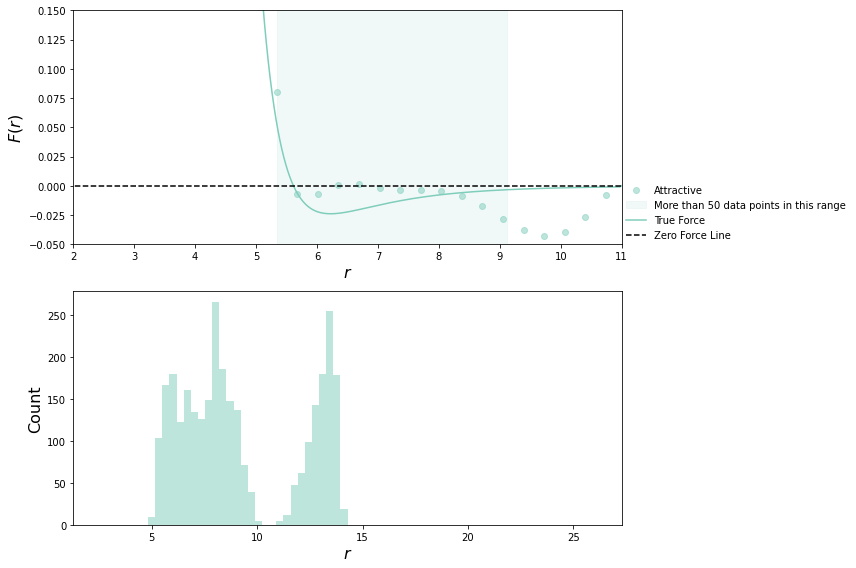

In [ ]:
fig, ax = plt.subplots(2,1,figsize = (12,8))
labels = ['1','R_mode' ,'R_N1','R_NT']
labels = ['Attractive','Repulsive','Repulsive+Attractive']

# when lampda = 1.0, we have lennard-jones potential, when lampda = 0 there are no interactions
for ee in range(1):
    #epsilon=(2)*(ee+1)
    epsilon = 0.5
    sigma = 5 #+ee*0.5
    if ee==0:
        lambda_param = 1 #0.2
    else:
        lambda_param = 0.5
    # Optional harmonic trap parameters
    use_harmonic_trap = False # Set to False to disable the trap
    kappa = 4.  # Spring constant for the harmonic trap
    Center = np.array([0,0]) #Center of harmonic trap
    pair_interactions = True # Set to True to enable Lennard-Jones pair interactions
    # Depth of the pair potential
    #sigma=1.0 # diameter of the particles
    
    # Parameters
    num_particles = 3 #10
    box_size = 20.0  # Box is a cube of size box_size x box_size
    temperature = 0.2  # Temperature (k_B * T)
    gamma = 10.0  # Friction coefficient
    dt = 0.01  # Time step
    frame = 20
    num_steps = 20000 #Number of simulation steps
    equilibration_steps = 1000 #Steps to equilibrate
    rcut=sigma*2+1
    name = "outputSig"+str(sigma)+"N"+str(num_particles)+"lambda"+str(lambda_param)+".xyz"
    # if ee==0:
    #     name = "outputExp"+str(sigma)+"N"+str(num_particles)+".xyz"
    #     rcut=sigma*2+1 #pair potential cutoffs, repulsive cutoff = 1.12*sigma
    # else:
    #     rcut = 1.12*sigma 
    #     name = "outputRep"+str(sigma)+"N"+str(num_particles)+".xyz"

    #Run the simulation
    if ee==0:
        OD_MD_SimulationLJPairs(num_particles,box_size,kappa,temperature,gamma,dt,num_steps,equilibration_steps,frame,use_harmonic_trap,name,Center,epsilon,sigma,rcut,lambda_param)
    df_atoms = parse_lammps_xyz(datadir + name)
    # pickle_filename = datadir + 'df_40particlesSim.csv'
    # df_atoms.to_csv(pickle_filename, index=False)
    # print(f"DataFrame saved to {pickle_filename}")
    #--------------------################---------------Creating B matrix--------------------################---------------#
    L_x, L_y = box_size, box_size
    #check if df_atoms has NaNs
    if df_atoms.isnull().values.any():
        print("DataFrame contains NaN values. Please check the input data.")
        continue
    # Parse the LAMMPS XYZ file
    print("Parsing LAMMPS XYZ file...",name)
    # get some useful quantities
    # if ee==0:
    R_NT,R_N1,R_mode,AvNN = Get_Distance_Quantities(df_atoms,L_x,L_y)
    
    #print("Average nearest neighbor distance:", R0,"Average number of neighbors:", AvNN)
    NumAtoms = np.max(df_atoms.id)
    NumBins = 70
    #IsoDistRange = rcut+1
    print("calculating forces ...")
    NumBasisFunctions = 10 #10 #*(ee+1)
    bin_edges = np.linspace(R_N1*0.5, R_NT*2, NumBins + 1)
    OnlyNN = False #True
    rcut_yes = False #True
    rcut_inf = R_NT #sigma+0.5
   # r_mods = [1.0,R_N1,np.mean(R_mode),R_NT]
    r_mod = R_N1
    Finfer,CCs,FF,TruForce,Rhist = estmateforcesMultiPairLJ(NumBins,df_atoms,L_x,L_y,dt,gamma,sigma,kappa,Center,bin_edges,epsilon,NumBasisFunctions,OnlyNN,rcut_inf,rcut_yes,r_mod,lambda_param)
    if ee==0:
        ax[1].hist(Rhist, bins=bin_edges, density=False, color=clrs[ee+1], alpha=0.5, label='Pairwise Distances')

    
    #Finfer,CCs,FF,TruForce = estmateforces2PairLJ(NumBins,df_atoms,L_x,L_y,dt,gamma,sigma,kappa,Center,bin_edges,epsilon)
    Rbins = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    if ee==0:
        ax[0].plot(Rbins,Finfer[0,:],marker = 'o',alpha = 0.5, color=clrs[ee+1],linestyle = '',label = labels[ee]) #r"Using exponential modulation $r_{\mathrm{mod}}$= "+labels[ee])
    else:
        ax[0].plot(Rbins,Finfer[0,:],marker = 'o', alpha = 0.5, color=clrs[ee+1],linestyle = '',label =  labels[ee]) #r"Using exponential modulation $r_{\mathrm{mod}}$= "+labels[ee])
    #ax.plot(Rbins,Finfer[1,:],marker = 'o', color=clrs[3],label = "Inferred Force in azumuthal")
    bin_edges = np.linspace(0, rcut, NumBins + 1)
    RhistA = np.array(Rhist)
    RhistA, _ = np.histogram(RhistA, bins=bin_edges)

    #RhistA = RhistA[RhistA > 10]
    #get the indices of the bin edges where RhistA is above 10
    IndexRhistA = np.where(RhistA > 50)[0]
    if ee==0:
        ax[0].fill_between([bin_edges[np.min(IndexRhistA)],bin_edges[np.max(IndexRhistA)+1]],[-1.5,-1.5],[1.0,1.0], color=clrs[ee+1], alpha=0.1, label='More than 50 data points in this range')
    else:
        ax[0].fill_between([bin_edges[np.min(IndexRhistA)],bin_edges[np.max(IndexRhistA)+1]],[-1.5,-1.5],[1.0,1.0], color=clrs[ee+1], alpha=0.1)


    rcut2 = rcut ** 2
    sigma6 = sigma ** 6
    sigma12 = sigma6 ** 2
    Rbins2 = np.linspace(0, rcut, NumBins*5)
    #printing lennard jones force as a function or Rbins
    force_scalar = np.zeros((len(Rbins2)))
    for rr in range(len(Rbins2)-1):
        r2 = np.dot(Rbins2[rr], Rbins2[rr])
        if r2 < rcut2:
            inv_r2 = 1.0 / r2
            inv_r6 = inv_r2 ** 3
            inv_r12 = inv_r6 ** 2
            inv_r13 = (1/np.sqrt(r2))*inv_r12
            inv_r7 = (1/np.sqrt(r2))*inv_r6
            #force_scalar[rr] = 4* epsilon * (sigma12*inv_r12 - sigma6 * inv_r6)/gamma
            force_scalar[rr] = -soft_lj_force(Rbins2[rr], epsilon, sigma, rcut_inf, lambda_param)/gamma #48 * epsilon * (sigma12*inv_r13 - 0.5*sigma6 * inv_r7)/gamma\

            #print("force_scalar",force_scalar[rr],"rr",rr,"Rbins2[rr]",Rbins2[rr],"sigma",sigma,"rcut_inf",rcut_inf,"lambda_param",lambda_param)

    ax[0].plot(Rbins2,force_scalar,color=clrs[ee+1],label = "True Force")
    #ax.plot(Rbins2,force_scalar,color=clrs[ee])
print("Rbinds2",Rbins2)
print("Force",force_scalar)
ax[0].plot([sigma*0.3,rcut+1],[0,0],color='black',linestyle='--',label = 'Zero Force Line')
ax[0].legend(frameon=False,loc = [1,0])
ax[0].set_ylim([-0.05,0.15])
ax[0].set_xlim([sigma-3,rcut])
ax[0].set_xlabel(r"$r$",fontsize = 16)
ax[0].set_ylabel(r"$F(r)$",fontsize = 16)
ax[1].set_xlabel(r"$r$",fontsize = 16)
ax[1].set_ylabel(r"Count",fontsize = 16)
fig.tight_layout()

fig.savefig(plotsdir + 'AttrRepulsion_Confined.pdf')
#fig.savefig(plotsdir + 'ODLJ6Pair_sigmas.pdf')

8.224607261230014
parameters for the force calculation 0.5 5.0 8.0 0.2 10.0 121 11.0
prefactor 2.0
dAdr 0.093312
(2 / A**3 - 1 / A**2) 19233.40718209925
prefactor 2.0
dAdr 0.0955614627121956
(2 / A**3 - 1 / A**2) 17640.556333245207
prefactor 2.0
dAdr 0.09785409981522182
(2 / A**3 - 1 / A**2) 16185.92292663122
prefactor 2.0
dAdr 0.10019052983935434
(2 / A**3 - 1 / A**2) 14856.960768354998
prefactor 2.0
dAdr 0.10257137719436779
(2 / A**3 - 1 / A**2) 13642.312774524591
prefactor 2.0
dAdr 0.10499727219734856
(2 / A**3 - 1 / A**2) 12531.693513963495
prefactor 2.0
dAdr 0.10746885110050647
(2 / A**3 - 1 / A**2) 11515.783820620936
prefactor 2.0
dAdr 0.10998675611898738
(2 / A**3 - 1 / A**2) 10586.136187666529
prefactor 2.0
dAdr 0.11255163545868514
(2 / A**3 - 1 / A**2) 9735.089797766299
prefactor 2.0
dAdr 0.11516414334405377
(2 / A**3 - 1 / A**2) 8955.694170219449
prefactor 2.0
dAdr 0.11782494004591998
(2 / A**3 - 1 / A**2) 8241.640517436204
prefactor 2.0
dAdr 0.12053469190929489
(2 / A**3 - 1

(-0.5, 2.0)

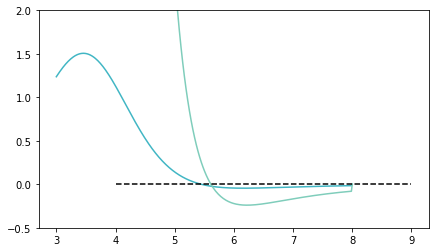

In [76]:
fig,ax = plt.subplots(1,1,figsize = (7,4))

Rbins2 = np.linspace(3, rcut, NumBins*5)
lambda_param = 0.2
print(rcut_inf)
print("parameters for the force calculation",epsilon,sigma,rcut,lambda_param,gamma,rcut2,np.sqrt(rcut2))
#printing lennard jones force as a function or Rbins
force_scalar = np.zeros((len(Rbins2)))
force_scalar2 = np.zeros((len(Rbins2)))
for rr in range(len(Rbins2)-1):
    r2 = np.dot(Rbins2[rr], Rbins2[rr])
    if r2 < rcut2:

        # inv_r2 = 1.0 / r2
        # inv_r6 = inv_r2 ** 3
        # inv_r12 = inv_r6 ** 2
        # inv_r13 = (1/np.sqrt(r2))*inv_r12
        # inv_r7 = (1/np.sqrt(r2))*inv_r6
        #force_scalar[rr] = 4* epsilon * (sigma12*inv_r12 - sigma6 * inv_r6)/gamma
        
        force_scalar[rr] = -soft_lj_force(Rbins2[rr], epsilon, sigma, rcut, lambda_param) #48 * epsilon * (sigma12*inv_r13 - 0.5*sigma6 * inv_r7)/gamma\
        
        force_scalar2[rr] = -lj_force(Rbins2[rr], epsilon, sigma, rcut)
        

        #print("force_scalar",force_scalar[rr],"rr",rr,"Rbins2[rr]",Rbins2[rr],"sigma",sigma,"rcut_inf",rcut_inf,"lambda_param",lambda_param)
#ax[0].plot(Rbins2,force_scalar,color=clrs[ee+1],label = "True Force")
ax.plot(Rbins2,force_scalar,color=clrs[ee+2],label = "True Force")
ax.plot(Rbins2,force_scalar2,color=clrs[ee+1],label = "True Force")
#ax.plot(Rbins,Finfer[0,:],marker = 'o',alpha = 0.5, color=clrs[1],linestyle = '',label = r"Using exponential modulation $r_{\mathrm{mod}}$= "+str(r_mod)) #r"Using exponential modulation $r_{\mathrm{mod}}$= "+labels[ee])

ax.plot([sigma*0.8,rcut+1],[0,0],color='black',linestyle='--',label = 'Zero Force Line')
ax.set_ylim([-0.5,2])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


(-0.05, 0.15)

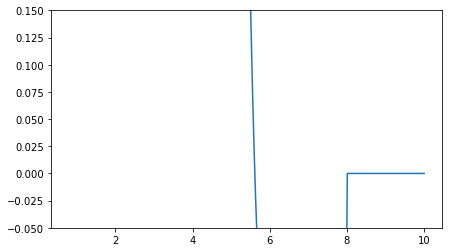

In [ ]:
def soft_lj_force(r, epsilon, sigma, rcut, lambda_param):
    n = 1
    alpha_lj = 0.5

    if r >= rcut:
        return 0.0

    lam_pow_n = lambda_param ** n
    const_factor = 4 * epsilon * lam_pow_n

    r6 = (r / sigma) ** 6
    A = alpha_lj * (1 - lambda_param)**2 + r6
    dAdr = 6 * (r / sigma)**5 / sigma

    dEdr = const_factor * (-2 / A**3 + 1 / A**2) * dAdr

    return -dEdr
fig, ax = plt.subplots(1,1,figsize = (7,4))
# Parameters
epsilon = 0.5
sigma = 5.0  # changed from 5 to 1
rcut = 8.
lambda_param = 1.0

# Generate r values
r_values = np.linspace(0.8, 10.0, 500)
forces = [soft_lj_force(r, epsilon, sigma, rcut, lambda_param) for r in r_values]

# Plot
ax.plot(r_values, forces)
# plt.xlabel('r')
# plt.ylabel('Force')
# plt.title('Soft-LJ Force (lambda=1.0, should match LJ)')
# plt.grid(True)
# plt.show()
ax.legend(frameon=False,loc = [1,0])
ax.set_ylim([-0.05,0.15])


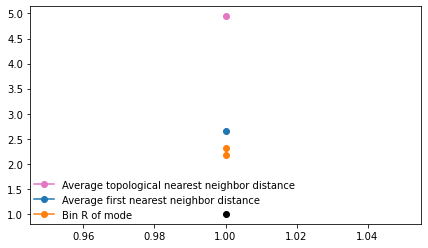

In [35]:
fig,ax = plt.subplots(1,1,figsize = (7,4))
ax.plot(1,1,marker  = 'o',color = 'black')
ax.plot(1, R_NT,marker='o',linestyle = '-',color = 'tab:pink', label='Average topological nearest neighbor distance')
ax.plot(1, R_N1,marker='o',linestyle = '-', label='Average first nearest neighbor distance')
ax.plot([1,1], [R_mode[0],R_mode[1]], marker='o',linestyle = '-', label='Bin R of mode')
ax.legend(frameon=False,loc = [0.,0])

calculating forces ...
r_modulation 1
shape of B (10, 10)
dimension of FF_accum (1, 10)
dimension of CCs (10, 50)


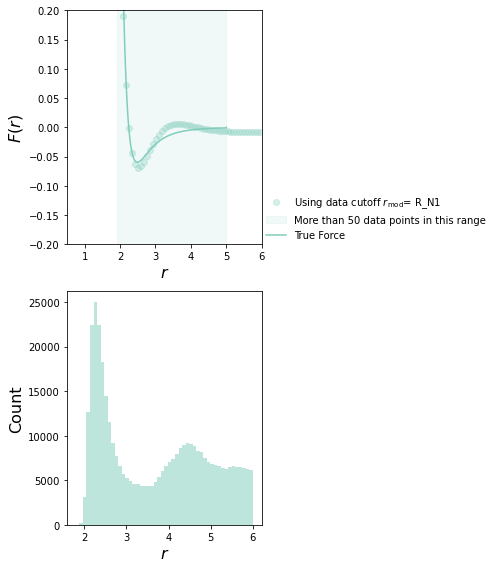

In [97]:
fig, ax = plt.subplots(2,1,figsize = (7,8))
labels = ['R_N1','R_N1*2','R_mode' ,'R_NT']
for ee in range(1):
    #epsilon=(2)*(ee+1)
    epsilon = 0.5
    sigma = 2 #+ee*0.5
    # Optional harmonic trap parameters
    use_harmonic_trap = False # Set to False to disable the trap
    kappa = 4.  # Spring constant for the harmonic trap
    Center = np.array([0,0]) #Center of harmonic trap
    pair_interactions = True # Set to True to enable Lennard-Jones pair interactions
    # Depth of the pair potential
    #sigma=1.0 # diameter of the particles
    rcut=sigma*2+1 #pair potential cutoffs, repulsive cutoff = 1.12*sigma
    # Parameters
    num_particles = 20
    box_size = 30.0  # Box is a cube of size box_size x box_size
    temperature = 0.2  # Temperature (k_B * T)
    gamma = 10.0  # Friction coefficient
    dt = 0.01  # Time step
    frame = 10
    num_steps = 100000 #Number of simulation steps
    equilibration_steps = 20000 #Steps to equilibrate
    if num_particles == 2:
        name = "outputExp"+str(sigma)+".xyz"
    else:
        name = "outputExp"+str(sigma)+"N"+str(num_particles)+".xyz"

    #Run the simulation
    #if ee==0:
    #    OD_MD_SimulationLJPairs(num_particles,box_size,kappa,temperature,gamma,dt,num_steps,equilibration_steps,frame,use_harmonic_trap,name,Center,epsilon,sigma,rcut)
    df_atoms = parse_lammps_xyz(datadir + name)
    #--------------------################---------------Creating B matrix--------------------################---------------#
    L_x, L_y = box_size, box_size

    # Parse the LAMMPS XYZ file
    
    # get some useful quantities
    #if ee==0:
    #   R_NT,R_N1,R_mode,AvNN = Get_Distance_Quantities(df_atoms,L_x,L_y)
    r_mods = [R_N1,R_N1*2,np.mean(R_mode),R_NT]
    #print("Average nearest neighbor distance:", R0,"Average number of neighbors:", AvNN)
    NumAtoms = np.max(df_atoms.id)
    NumBins = 50
    IsoDistRange = rcut+1
    print("calculating forces ...")
    NumBasisFunctions = 10 #10 #*(ee+1)
    bin_edges = np.linspace(sigma-0.2, IsoDistRange, NumBins + 1)
    OnlyNN = False #True
    rcut_yes = False #True
    rcut_inf = r_mods[ee]
    Finfer,CCs,FF,TruForce,Rhist = estmateforcesMultiPairLJ(NumBins,df_atoms,L_x,L_y,dt,gamma,sigma,kappa,Center,bin_edges,epsilon,NumBasisFunctions,OnlyNN,rcut_inf,rcut_yes,1)
    #if ee==0:
    ax[1].hist(Rhist, bins=bin_edges, density=False, color=clrs[ee+1], alpha=0.5, label='Pairwise Distances')
    
    #Finfer,CCs,FF,TruForce = estmateforces2PairLJ(NumBins,df_atoms,L_x,L_y,dt,gamma,sigma,kappa,Center,bin_edges,epsilon)
    Rbins = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    if ee==0:
        ax[0].plot(Rbins,Finfer[0,:],marker = 'o',alpha = 0.3, color=clrs[ee+1],linestyle = '',label = r"Using data cutoff $r_{\mathrm{mod}}$= "+labels[ee])
    else:
        ax[0].plot(Rbins,Finfer[0,:],marker = 'o', alpha = 0.3, color=clrs[ee+1],linestyle = '',label = r"Using exponential modulation $r_{\mathrm{mod}}$= "+labels[ee])
    #ax.plot(Rbins,Finfer[1,:],marker = 'o', color=clrs[3],label = "Inferred Force in azumuthal")
    bin_edges = np.linspace(0, rcut, NumBins + 1)
    RhistA = np.array(Rhist)
    RhistA, _ = np.histogram(RhistA, bins=bin_edges)

    #RhistA = RhistA[RhistA > 10]
    #get the indices of the bin edges where RhistA is above 10
    IndexRhistA = np.where(RhistA > 50)[0]
    if ee==0:
        ax[0].fill_between([bin_edges[np.min(IndexRhistA)],bin_edges[np.max(IndexRhistA)+1]],[-1.5,-1.5],[1.0,1.0], color=clrs[ee+1], alpha=0.1, label='More than 50 data points in this range')
    else:
        ax[0].fill_between([bin_edges[np.min(IndexRhistA)],bin_edges[np.max(IndexRhistA)+1]],[-1.5,-1.5],[1.0,1.0], color=clrs[ee+1], alpha=0.1)


    rcut2 = rcut ** 2
    sigma6 = sigma ** 6
    sigma12 = sigma6 ** 2
    Rbins2 = np.linspace(0, rcut, NumBins*5)
    #printing lennard jones force as a function or Rbins
    force_scalar = np.zeros((len(Rbins2)))
    for rr in range(len(Rbins2)-1):
        r2 = np.dot(Rbins2[rr], Rbins2[rr])
        if r2 < rcut2:
            inv_r2 = 1.0 / r2
            inv_r6 = inv_r2 ** 3
            inv_r12 = inv_r6 ** 2
            inv_r13 = (1/np.sqrt(r2))*inv_r12
            inv_r7 = (1/np.sqrt(r2))*inv_r6
            #force_scalar[rr] = 4* epsilon * (sigma12*inv_r12 - sigma6 * inv_r6)/gamma
            force_scalar[rr] = 48 * epsilon * (sigma12*inv_r13 - 0.5*sigma6 * inv_r7)/gamma

    ax[0].plot(Rbins2,force_scalar,color=clrs[ee+1],label = "True Force")
    #ax.plot(Rbins2,force_scalar,color=clrs[ee])
ax[0].legend(frameon=False,loc = [1,0])
ax[0].set_ylim([-0.2,0.2])
ax[0].set_xlim([0.5,rcut+1])
ax[0].set_xlabel(r"$r$",fontsize = 16)
ax[0].set_ylabel(r"$F(r)$",fontsize = 16)
ax[1].set_xlabel(r"$r$",fontsize = 16)
ax[1].set_ylabel(r"Count",fontsize = 16)
fig.tight_layout()

# fig.savefig(plotsdir + 'Arbitrary6ParticleNN_sigmaFrame2.pdf')
# fig.savefig(plotsdir + 'ODLJ6Pair_sigmas.pdf')

In [ ]:
4.654456409558228

IndexRhistA [16 17 18 19 20 21 22 23 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39
 40 41 42 43 44 45 46 47 48 49]
RhistA [    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0    15   814  5850 11180 11223  8762  6860  5267  4187
  3469  2869  2594  2577  2494  2424  2388  2408  2428  2459  2551  2675
  2426  2451  2563  2690  2771  2955  2952  3107  2993  3057  3056  2958
  3084  3222]


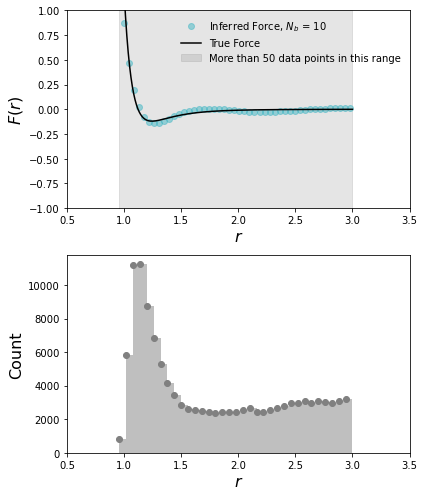

In [68]:
fig,ax = plt.subplots(2,1,figsize = (6,7))
FinferN10 = Finfer[0,:]
#ax.plot(Rbins,FinferN5 ,marker = 'o',alpha = 0.5, color=clrs[1],linestyle = '',label = r"Inferred Force, $N_{b}$ = 5")
ax[0].plot(Rbins,FinferN10 ,marker = 'o',alpha = 0.5, color=clrs[2],linestyle = '',label = r"Inferred Force, $N_{b}$ = 10")
#ax[0].fill_between()
#ax[0].plot(Rbins,FinferN15 ,marker = 'o',alpha = 0.5, color=clrs[3],linestyle = '',label = r"Inferred Force, $N_{b}$ = 10")
#ax.plot(Rbins,FinferN15 ,marker = 'o',alpha = 0.5, color=clrs[2],linestyle = '',label = r"Inferred Force, $N_{b}$ = 15")
ax[0].plot(Rbins2,force_scalar,color='black',label = "True Force")
ax[0].set_ylim([-1,1])
ax[0].set_xlim([0.5,rcut+0.5])
ax[0].set_xlabel(r"$r$",fontsize = 16)
ax[0].set_ylabel(r"$F(r)$",fontsize = 16)
# from Rhist get rmin and rmax where the histogram count is above 10
bin_edges = np.linspace(0, rcut, NumBins + 1)
RhistA = np.array(Rhist)
RhistA, _ = np.histogram(RhistA, bins=bin_edges)

#RhistA = RhistA[RhistA > 10]
#get the indices of the bin edges where RhistA is above 10
IndexRhistA = np.where(RhistA > 50)[0]
print( "IndexRhistA",IndexRhistA)

print("RhistA",RhistA)
ax[1].hist(Rhist, bins=bin_edges, density=False, color='gray', alpha=0.5, label='Pairwise Distances')
ax[1].plot(bin_edges[np.min(IndexRhistA):np.max(IndexRhistA)+1], RhistA[np.min(IndexRhistA):np.max(IndexRhistA)+1], marker='o', color='grey', linestyle='', label='Histogram of Pairwise Distances')

ax[0].fill_between([bin_edges[np.min(IndexRhistA)],bin_edges[np.max(IndexRhistA)+1]],[-1.5,-1.5],[1.0,1.0], color='grey', alpha=0.2, label='More than 50 data points in this range')
#ax[1].set_ylim([-1.5,1.])
ax[0].legend(frameon=False)
ax[1].set_xlim([0.5,rcut+0.5])
ax[1].set_xlabel(r"$r$",fontsize = 16)
ax[1].set_ylabel(r"Count",fontsize = 16)
fig.tight_layout()
fig.savefig(plotsdir + 'Arbitrary6Particle_sigmaFrame2.pdf')

Global force inference:

## Creating data: 2D well with overdamped dynamics. 1 simulation and force

TO do list:
Notes: my inferred force is not great, especially for off-centre forces. Force profile sort of skewed.
--- Inferred force too low for high X low Y and high Y low X
- Mess with diff(x) to see if the time where velocity is evaluated is causing bias
- Check all averages .. 

Step 0/50000
Step 1000/50000
Step 2000/50000
Step 3000/50000
Step 4000/50000
Step 5000/50000
Step 6000/50000
Step 7000/50000
Step 8000/50000
Step 9000/50000
Step 10000/50000
Step 11000/50000
Step 12000/50000
Step 13000/50000
Step 14000/50000
Step 15000/50000
Step 16000/50000
Step 17000/50000
Step 18000/50000
Step 19000/50000
Step 20000/50000
Step 21000/50000
Step 22000/50000
Step 23000/50000
Step 24000/50000
Step 25000/50000
Step 26000/50000
Step 27000/50000
Step 28000/50000
Step 29000/50000
Step 30000/50000
Step 31000/50000
Step 32000/50000
Step 33000/50000
Step 34000/50000
Step 35000/50000
Step 36000/50000
Step 37000/50000
Step 38000/50000
Step 39000/50000
Step 40000/50000
Step 41000/50000
Step 42000/50000
Step 43000/50000
Step 44000/50000
Step 45000/50000
Step 46000/50000
Step 47000/50000
Step 48000/50000
Step 49000/50000
Simulation completed. Output written to outputHomeODLJ1.0.xyz
Minimum force -2.396429260839198for params eps1 sig1.0 rc4.0
calculating forces ...
shape of B (2, 2)

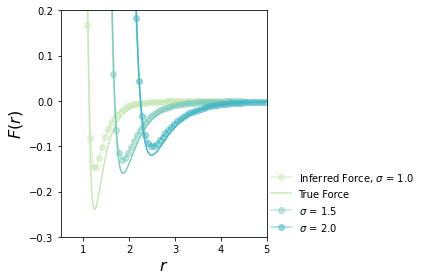

In [42]:
fig, ax = plt.subplots(figsize = (6,4))
for ee in range(3):
    #epsilon=(2)*(ee+1)
    epsilon = 1
    sigma = (ee*0.5)+1
    # Optional harmonic trap parameters
    use_harmonic_trap = False # Set to False to disable the trap
    kappa = 4.  # Spring constant for the harmonic trap
    Center = np.array([0,0]) #Center of harmonic trap
    pair_interactions = True # Set to True to enable Lennard-Jones pair interactions
    # Depth of the pair potential
    #sigma=1.0 # diameter of the particles
    rcut=sigma+3 #pair potential cutoffs, repulsive cutoff = 1.12*sigma
    # Parameters
    num_particles = 6 
    box_size = 10.0  # Box is a cube of size box_size x box_size
    temperature = 0.2  # Temperature (k_B * T)
    gamma = 10.0  # Friction coefficient
    dt = 0.01  # Time step
    frame=5
    num_steps = 30000 #Number of simulation steps
    equilibration_steps = 20000 #Steps to equilibrate
    name = "outputHomeODLJ"+str(sigma)+".xyz"

    #Run the simulation
    OD_MD_SimulationLJPairs(num_particles,box_size,kappa,temperature,gamma,dt,num_steps,equilibration_steps,frame,use_harmonic_trap,name,Center,epsilon,sigma,rcut)
    #--------------------################---------------Creating B matrix--------------------################---------------#
    L_x, L_y = box_size, box_size

    # Parse the LAMMPS XYZ file
    df_atoms = parse_lammps_xyz(datadir + name)
    NumAtoms = np.max(df_atoms.id)
    NumBins = 50
    IsoDistRange = rcut
    print("calculating forces ...")
        
    bin_edges = np.linspace(sigma-0.2, IsoDistRange, NumBins + 1)
    Finfer,CCs,FF,TruForce =estmateforces2PairLJ(NumBins,df_atoms,L_x,L_y,dt,gamma,sigma,kappa,Center,bin_edges,epsilon)
    Rbins = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    if ee==0:
        ax.plot(Rbins,Finfer[0,:],marker = 'o',alpha = 0.5, color=clrs[ee],label = r"Inferred Force, $\sigma$ = "+str(sigma))
    else:
        ax.plot(Rbins,Finfer[0,:],marker = 'o', alpha = 0.5, color=clrs[ee],label = r"$\sigma$ = "+str(sigma))
    #ax.plot(Rbins,Finfer[1,:],marker = 'o', color=clrs[3],label = "Inferred Force in azumuthal")

    rcut2 = rcut ** 2
    sigma6 = sigma ** 6
    sigma12 = sigma6 ** 2
    Rbins2 = np.linspace(0, rcut, NumBins*5)
    #printing lennard jones force as a function or Rbins
    force_scalar = np.zeros((len(Rbins2)))
    for rr in range(len(Rbins2)-1):
        r2 = np.dot(Rbins2[rr], Rbins2[rr])
        if r2 < rcut2:
            inv_r2 = 1.0 / r2
            inv_r6 = inv_r2 ** 3
            inv_r12 = inv_r6 ** 2
            inv_r13 = (1/np.sqrt(r2))*inv_r12
            inv_r7 = (1/np.sqrt(r2))*inv_r6
            #force_scalar[rr] = 4* epsilon * (sigma12*inv_r12 - sigma6 * inv_r6)/gamma
            force_scalar[rr] = 48 * epsilon * (sigma12*inv_r13 - 0.5*sigma6 * inv_r7)/gamma
    #ax.plot(Rbins2-0.5,force_scalar,marker = 'o', color=clrs[0],label = "Potential")
    if ee==0:
        ax.plot(Rbins2,force_scalar,color=clrs[ee],label = "True Force")
    else:
        ax.plot(Rbins2,force_scalar,color=clrs[ee])
    #ax.plot([1.12,1.12],[-20,20],linestyle = '--',color = 'grey')
    #ax.plot([1.,1.],[-20,20],linestyle = '--',color = 'grey')
    #ax.plot([0,3.0],[0,0],linestyle = ':',color = 'grey')
    #ax.plot(Rbins,TruForce[:],color=clrs[ee],linestyle = ':')
    print(np.shape(TruForce))
    
    
    #print(FF)
    #print(CCs)
ax.legend(frameon=False,loc = [1,0])
ax.set_ylim([-0.3,0.2])
ax.set_xlim([0.5,rcut])
ax.set_xlabel(r"$r$",fontsize = 16)
ax.set_ylabel(r"$F(r)$",fontsize = 16)
fig.tight_layout()

#fig.savefig(plotsdir + 'ODLJ2Pair_sigmas.pdf')
fig.savefig(plotsdir + 'ODLJ6Pair_sigmas.pdf')

[[0.02860348 0.19539896]]
[[ 3.99882223  3.7038375   3.42936735  3.17459018  2.93853308  2.72013774
   2.51830819  2.33194476  2.15996798  2.00133472  1.85504879  1.72016733
   1.59580414  1.48113088  1.37537663  1.27782644  1.18781913  1.1047446
   1.02804092  0.95719127  0.89172083  0.83119383  0.77521051  0.72340444
   0.67543974  0.63100871  0.58982944  0.55164365  0.51621473  0.48332587
   0.45277839  0.42439015  0.39799415  0.37343721  0.35057878  0.32928988
   0.30945203  0.29095644  0.27370309  0.25760003  0.24256269  0.22851323
   0.21537997  0.20309688  0.19160311  0.18084255  0.17076343  0.16131795
   0.15246197  0.14415473]
 [73.70622051 60.10447208 48.95182725 39.79764166 32.27722409 26.09477028
  21.009826   16.82652008 13.38497752 10.55445366  8.22783035  6.31719335
   4.75027005  3.46755339  2.41997487  1.56701751  0.87518241  0.31674024
  -0.13128749 -0.48796106 -0.76910451 -0.98786502 -1.15517274 -1.28011919
  -1.37026934 -1.43191926 -1.47030924 -1.48980028 -1.4940204

(50,)


(0.5, 4.0)

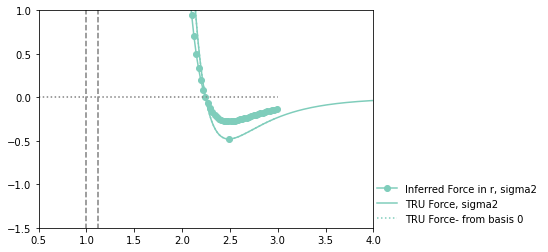

In [11]:
fig, ax = plt.subplots()
ax.plot(Rbins,-Finfer[0,:],marker = 'o', color=clrs[ee],label = "Inferred Force in r, sigma"+str(sigma))
    #ax.plot(Rbins,Finfer[1,:],marker = 'o', color=clrs[3],label = "Inferred Force in azumuthal")

rcut2 = rcut ** 2
sigma6 = sigma ** 6
sigma12 = sigma6 ** 2
Rbins2 = np.linspace(0, rcut, NumBins*5)
#printing lennard jones force as a function or Rbins
force_scalar = np.zeros((len(Rbins2)))
for rr in range(len(Rbins2)-1):
    r2 = np.dot(Rbins2[rr], Rbins2[rr])
    if r2 < rcut2:
        inv_r2 = 1.0 / r2
        inv_r6 = inv_r2 ** 3
        inv_r12 = inv_r6 ** 2
        inv_r13 = (1/np.sqrt(r2))*inv_r12
        inv_r7 = (1/np.sqrt(r2))*inv_r6
        #force_scalar[rr] = 4* epsilon * (sigma12*inv_r12 - sigma6 * inv_r6)/gamma
        force_scalar[rr] = 48 * epsilon * (sigma12*inv_r13 - 0.5*sigma6 * inv_r7)/gamma
#rmin is the sixth root of 13/3.5
sixthroot = (13/3.5)**(1/6)
rmin = sigma* sixthroot
Fmin = 48 * epsilon * (sigma12*(1/rmin)**13 - 0.5*sigma6 * (1/rmin)**7)/gamma
#ax.plot(Rbins2-0.5,force_scalar,marker = 'o', color=clrs[0],label = "Potential")
ax.plot(Rbins2,force_scalar,color=clrs[ee],label = "TRU Force, sigma"+str(sigma))
ax.plot([rmin],[Fmin],marker = 'o', color=clrs[ee])
ax.plot([1.12,1.12],[-20,20],linestyle = '--',color = 'grey')
ax.plot([1.,1.],[-20,20],linestyle = '--',color = 'grey')
ax.plot([0,3.0],[0,0],linestyle = ':',color = 'grey')
ax.plot(Rbins,TruForce[:],color=clrs[ee],linestyle = ':',label = "TRU Force- from basis 0")
print(np.shape(TruForce))
ax.legend(frameon=False,loc = [1,0])
ax.set_ylim([-1.5,1] )
ax.set_xlim([0.5,4])